# M4: Molecular Graph Baselines (GCN / GIN)

Goal: represent molecules as graphs and compare two learned graph models, GCN and GIN, against the Morgan baseline on the **same Murcko scaffold split** used in M3.

The scaffold split is kept identical so M4 and M3 are directly comparable on "unseen scaffold" generalization.


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from rdkit import Chem
from torch_geometric.loader import DataLoader

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

sys.path.insert(0, str(PROJECT_ROOT / "src" / "models"))
from graph_baseline import (
    GCNRegressor,
    GINRegressor,
    distribution_stats,
    predict,
    scaffold_split_indices,
    smiles_to_graph,
    train_epoch,
)

## 1. Load the M1 dataset and reuse the M3 scaffold split

Same molecules, same pIC50 target, same train/test indices as M3.


In [2]:
final_df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "egfr_activity_final.csv")
print(f"molecules: {len(final_df):,}")

smiles_list = final_df["canonical_smiles"].tolist()
y = final_df["pIC50"].to_numpy(dtype=np.float32)

train_idx, test_idx, scaffold_stats = scaffold_split_indices(smiles_list, test_size=0.2)
y_train, y_test = y[train_idx], y[test_idx]

print(f"train={len(train_idx):,}  test={len(test_idx):,}")
print(f"scaffolds: {scaffold_stats['n_scaffolds']:,} "
      f"(train {scaffold_stats['scaffolds_train']:,}, "
      f"test {scaffold_stats['scaffolds_test']:,})")
print(f"pIC50 mean train/test: {y_train.mean():.3f} / {y_test.mean():.3f}")

molecules: 10,161
train=8,128  test=2,033
scaffolds: 3,641 (train 1,608, test 2,033)
pIC50 mean train/test: 7.010 / 6.676


## 2. SMILES -> molecular graph

Each molecule becomes a PyTorch Geometric `Data` object with:

- atom features (atomic number, degree, charge, hybridization, aromatic, H count, ring membership);
- edge index (undirected bonds);
- bond features (bond type, conjugation, ring membership).


In [3]:
graphs = []
invalid = 0
for smi, target in zip(smiles_list, y):
    graph = smiles_to_graph(smi, float(target))
    if graph is None:
        invalid += 1
        continue
    graphs.append(graph)

assert invalid == 0, f"{invalid} invalid SMILES"
node_feature_dim = graphs[0].x.shape[1]
n_nodes_mean = float(np.mean([g.num_nodes for g in graphs]))
n_edges_mean = float(np.mean([g.num_edges for g in graphs]))
print(f"graphs: {len(graphs):,}")
print(f"node feature dim: {node_feature_dim}, edge feature dim: {graphs[0].edge_attr.shape[1]}")
print(f"mean nodes/graph: {n_nodes_mean:.1f}, mean edges/graph: {n_edges_mean:.1f}")

graphs_train = [graphs[i] for i in train_idx]
graphs_test = [graphs[i] for i in test_idx]

graphs: 10,161
node feature dim: 32, edge feature dim: 7
mean nodes/graph: 34.1, mean edges/graph: 75.1


## 3. GCN and GIN

Both models are two-layer graph networks with mean + max pooling and a linear head. They are deliberately small so the baseline is easy to understand and fast to train.


In [4]:
def evaluate(y_true, y_pred):
    from scipy.stats import pearsonr, spearmanr
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
        "Pearson_r": pearsonr(y_true, y_pred)[0],
        "Spearman_rho": spearmanr(y_true, y_pred)[0],
    }

def run_model(name, factory, seed=42):
    torch.manual_seed(seed)
    model = factory()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    train_loader = DataLoader(graphs_train, batch_size=256, shuffle=True)
    test_loader = DataLoader(graphs_test, batch_size=256, shuffle=False)
    for epoch in range(1, 31):
        loss = train_epoch(model, train_loader, optimizer)
        if epoch % 10 == 0 or epoch == 30:
            print(f"  {name} epoch {epoch:02d}/30 train_loss={loss:.4f}")
    y_pred = predict(model, test_loader)
    return evaluate(y_test, y_pred)

metrics = {
    "GCN": run_model("GCN", lambda: GCNRegressor(node_feature_dim)),
    "GIN": run_model("GIN", lambda: GINRegressor(node_feature_dim)),
}
print("training done")

  GCN epoch 10/30 train_loss=1.4802
  GCN epoch 20/30 train_loss=1.2711
  GCN epoch 30/30 train_loss=1.1905
  GIN epoch 10/30 train_loss=1.4232
  GIN epoch 20/30 train_loss=1.1866
  GIN epoch 30/30 train_loss=1.1164
training done


## 4. Results under the same scaffold split


In [5]:
print("Scaffold-split test metrics:")
for model_name, metric in metrics.items():
    print(f"\n{model_name}:")
    for key, value in metric.items():
        print(f"  {key}: {value:.4f}")

Scaffold-split test metrics:

GCN:
  MAE: 0.9652
  RMSE: 1.1958
  R2: 0.1361
  Pearson_r: 0.4051
  Spearman_rho: 0.3871

GIN:
  MAE: 0.9136
  RMSE: 1.1379
  R2: 0.2178
  Pearson_r: 0.4688
  Spearman_rho: 0.4508


## 5. Compare with M3 Morgan baseline

Load the saved M3 scaffold-split metrics and plot all four models side by side.


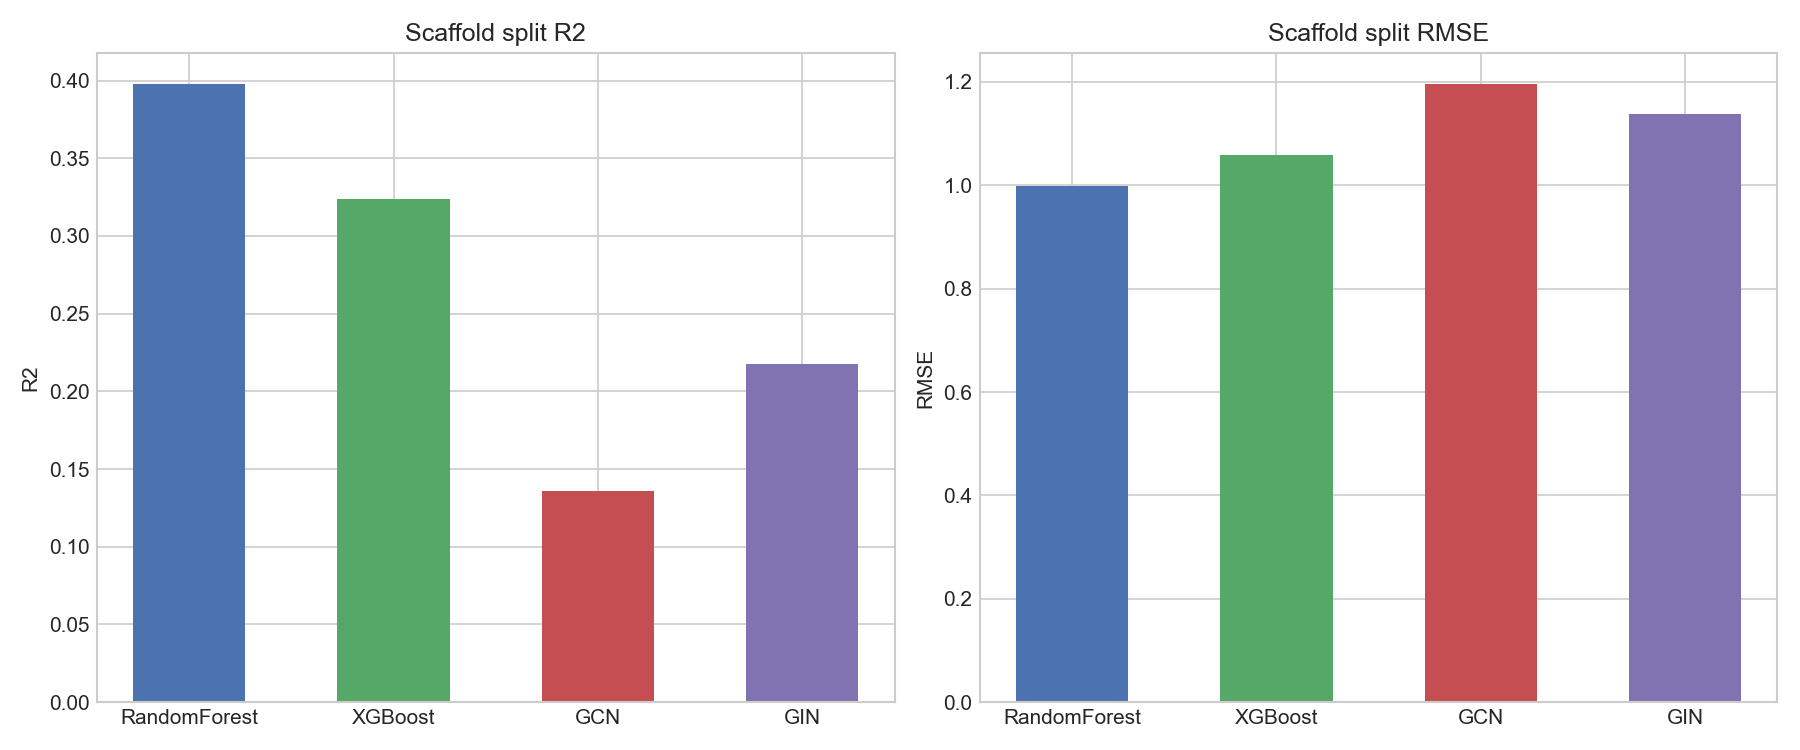

In [6]:
import json

m3_path = RESULTS_DIR / "m3_morgan_split_comparison_results.json"
m3 = json.loads(m3_path.read_text())
m3_scaffold = m3["splits"]["scaffold"]["metrics"]

model_names = ["RandomForest", "XGBoost", "GCN", "GIN"]
r2_values = [
    m3_scaffold["RandomForest"]["R2"],
    m3_scaffold["XGBoost"]["R2"],
    metrics["GCN"]["R2"],
    metrics["GIN"]["R2"],
]
rmse_values = [
    m3_scaffold["RandomForest"]["RMSE"],
    m3_scaffold["XGBoost"]["RMSE"],
    metrics["GCN"]["RMSE"],
    metrics["GIN"]["RMSE"],
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(model_names))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
axes[0].bar(x, r2_values, 0.55, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].set_ylabel("R2")
axes[0].set_title("Scaffold split R2")
axes[1].bar(x, rmse_values, 0.55, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylabel("RMSE")
axes[1].set_title("Scaffold split RMSE")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "m4_graph_baseline_scaffold_comparison.png", dpi=150)
plt.show()

## 6. How to interpret the results

1. GCN and GIN are much worse than the Morgan baseline under the strict scaffold split.
2. This does not mean graph models are useless; it means a small, lightly-tuned GNN does not automatically beat a fixed fingerprint, especially for unseen scaffolds.
3. M4/M5 comparisons should keep this exact scaffold split so every model faces the same test molecules.
4. Later improvements could include more layers, better features, larger hidden size, more epochs, or edge-feature-aware message passing.
